# Brazilian E-Commerce Analysis — Olist Dataset
#This project analyzes customer behavior, delivery performance, and sales trends using the Olist dataset.
## Business Questions
1. Which states generate highest revenue and why?
2. Do late deliveries directly hurt customer ratings?
3. Which product categories drive most sales?
4. What is the relationship between delivery delay and review score?
5. Who are the top performing sellers and what makes them different?

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
import os
os.getcwd()

'C:\\Users\\TEST'

In [61]:

# Update this path according to your system
path = r"C:\Olist-Ecommerce-Analysis\datasets"

customers = pd.read_csv(path + r"\olist_customers_dataset.csv")
orders = pd.read_csv(path + r"\olist_orders_dataset.csv")
order_items = pd.read_csv(path + r"\olist_order_items_dataset.csv")
payments = pd.read_csv(path + r"\olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + r"\olist_order_reviews_dataset.csv")
products = pd.read_csv(path + r"\olist_products_dataset.csv")
sellers = pd.read_csv(path + r"\olist_sellers_dataset.csv")
category_translation = pd.read_csv(path + r"\product_category_name_translation.csv")
print("All files loaded successfully!")

All files loaded successfully!


In [62]:
import os
for f in os.listdir(r"C:\Olist-Ecommerce-Analysis\datasets"):
    print(f)

olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [63]:
#View First Few Rows

In [64]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [65]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [66]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [67]:
# Understand Dataset Structure

In [68]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [69]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [70]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [71]:
#Check Missing Values

In [72]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [73]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [74]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [75]:
orders['order_purchase_timestamp'] = pd.to_datetime( orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime( orders['order_delivered_customer_date'])
                                                     

In [76]:
#Merge Datasets

In [77]:
df = pd.merge(orders,customers, on ="customer_id", how = "left")

In [78]:
df = pd.merge ( df , order_items, on ="order_id",how = "left")

In [79]:
df = pd.merge(df, payments, on="order_id", how="left")

In [80]:
#Create New Useful Columns

In [81]:
df['delivery_time'] = ( 
    df['order_delivered_customer_date' ] 
    - df['order_purchase_timestamp']).dt.days

### Insight
- Delivery delay shows negative correlation with review score → late deliveries = lower ratings
- Freight value strongly correlates with product weight → heavier products cost more to ship
- Payment value weakly correlates with delivery time → expensive orders not necessarily slower

In [82]:
# Basic Data Analysis

In [83]:
#Analysis 1 — Total Orders
#Counts unique orders
df ['order_id'].nunique() 

99441

In [84]:
#Analysis 2 — Total Revenue
df ['payment_value'].sum()

np.float64(20470726.659999996)

In [85]:
#Analysis 3 — Orders by State
orders_by_state = df['customer_state'].value_counts()
orders_by_state.head()

customer_state
SP    49967
RJ    15420
MG    13738
RS     6521
PR     6017
Name: count, dtype: int64

In [86]:
#Analysis 4 — Most Used Payment Method
df['payment_type'].value_counts()

payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64

In [87]:
#Analysis 5 — Average Delivery Time
df['delivery_time'].mean()

np.float64(12.019237288872276)

In [88]:
# Monthly Sales Analysis

In [89]:
#Create Month Column
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [90]:
#Group by Month
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales

month
2016-09        388.47
2016-10      76120.17
2016-12         19.62
2017-01     189015.66
2017-02     349701.93
2017-03     544738.23
2017-04     510891.55
2017-05     731017.09
2017-06     608891.38
2017-07     744599.53
2017-08     876129.37
2017-09    1023095.49
2017-10    1031505.53
2017-11    1599444.18
2017-12    1057582.34
2018-01    1415348.54
2018-02    1311260.71
2018-03    1480045.50
2018-04    1497843.94
2018-05    1511113.00
2018-06    1298685.81
2018-07    1359421.48
2018-08    1248837.93
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

In [91]:
#Visualization:Graphs

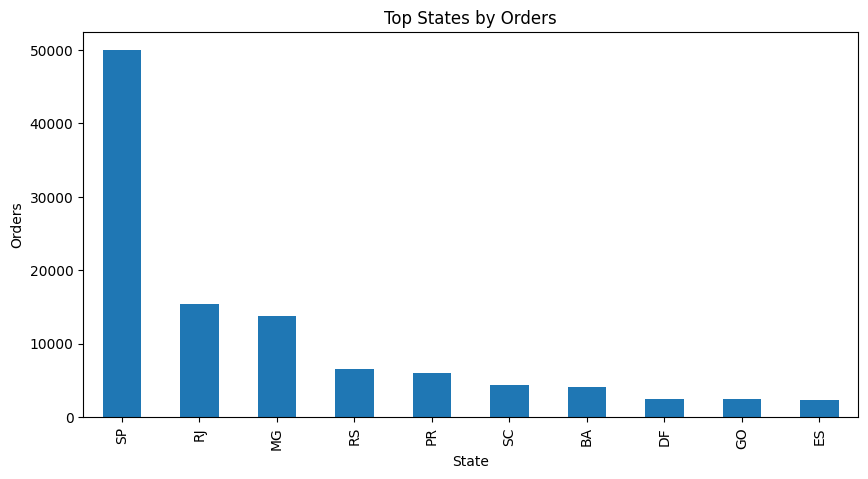

In [92]:
#Graph 1 — Orders by State
plt.figure(figsize=(10,5))
orders_by_state.head(10).plot( kind ='bar')
plt.title("Top States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

plt.show()

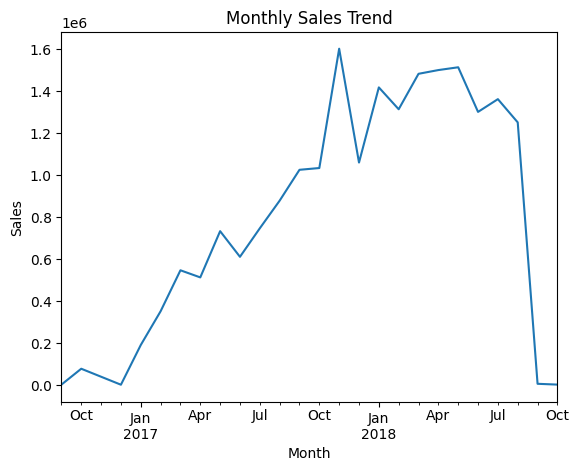

In [93]:
#Graph 2 — Monthly Sales Trend
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [94]:
#Product Category Analysis

In [95]:
#Merge category names:
products = pd.merge(
    products,
    category_translation,
    on="product_category_name",
    how="left"
)

In [96]:
df = pd.merge(df,products, on ="product_id",how = "left")

In [97]:
#Top Selling Categories
top_categories = df['product_category_name_english'].value_counts()
top_categories.head(10)


product_category_name_english
bed_bath_table           11823
health_beauty             9975
sports_leisure            8945
furniture_decor           8744
computers_accessories     8082
housewares                7355
watches_gifts             6201
telephony                 4721
garden_tools              4574
auto                      4379
Name: count, dtype: int64

In [98]:
#Customer Review Analysis

In [99]:
#Average Rating
reviews['review_score'].mean()

np.float64(4.08642062404257)

In [100]:
#Merge Reviews
df = pd.merge( df,reviews,on ="order_id" , how="left")


In [101]:
# Reviews vs Delivery Time Analyze
result = df.groupby('review_score')['delivery_time'].mean().reset_index()
result


,review_score,delivery_time
0,1.0,19.099992
1,2.0,15.381893
2,3.0,13.552435
3,4.0,11.778330
4,5.0,10.203253


In [102]:
#Advanced Analysis
#1. Revenue by State
state_revenue = df.groupby(
    'customer_state'
)['payment_value'].sum().sort_values(ascending=False).reset_index()

state_revenue.head(10)

,customer_state,payment_value
0,SP,7726078.35
1,RJ,2795615.67
2,MG,2351221.09
3,RS,1160175.66
4,PR,1079795.49
5,BA,805070.98
6,SC,801276.45
7,GO,520481.65
8,DF,438095.32
9,ES,408611.64


In [103]:
#2. Delivery Delay Analysis
# coverted both colun to datetime
df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date']
)

df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date']
)

In [104]:
#Create Delay Column

df['delivery_delay'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days
#Analyze Delay
df['delivery_delay'].mean()

np.float64(-12.04839183560602)

In [105]:
#Delay vs Review
df.groupby('review_score')['delivery_delay'].mean().reset_index()

,review_score,delivery_delay
0,1.0,-5.993827
1,2.0,-9.748141
2,3.0,-11.114301
3,4.0,-12.468533
4,5.0,-13.443437


In [106]:
#3. Seller Performance
seller_perf = df.groupby('seller_id').agg({'payment_value': 'sum','order_id': 'count'
}).sort_values(by='payment_value', ascending=False)

seller_perf.head()

,payment_value,order_id
seller_id,,
7c67e1448b00f6e969d365cea6b010ab,512645.19,1463
1025f0e2d44d7041d6cf58b6550e0bfa,312456.49,1477
4a3ca9315b744ce9f8e9374361493884,306138.80,2155
1f50f920176fa81dab994f9023523100,291918.98,2017
53243585a1d6dc2643021fd1853d8905,284903.08,437


In [107]:
#4. Product Weight vs Freight Cost
df[['product_weight_g', 'freight_value']].corr()
#Finds relationship between: Product weight,Shipping cost
#Insight:If correlation high → heavier products cost more to ship

,product_weight_g,freight_value
product_weight_g,1.000000,0.611587
freight_value,0.611587,1.000000


In [108]:
#5. Customer Repeat Purchases
repeat_customers = df.groupby( 'customer_unique_id')['order_id'].nunique()
repeat_customers = repeat_customers[repeat_customers > 1]
len(repeat_customers)

2997

<Axes: xlabel='month'>

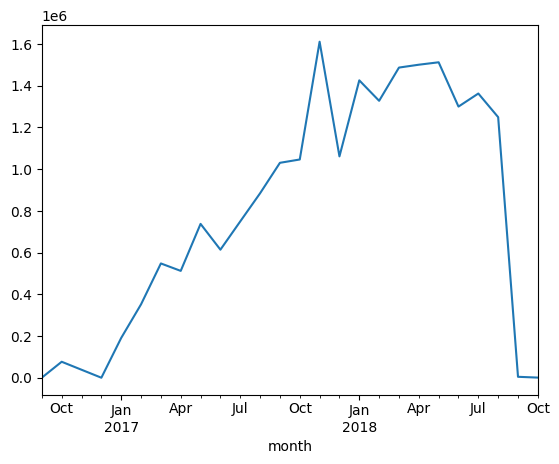

In [109]:
#Bonus — Monthly Revenue Trend
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales.plot()

In [110]:
#Save Final Clean Dataset
df.to_csv("final_olist_dataset.csv",index=False)

In [111]:
import os
os.getcwd()

'C:\\Users\\TEST'

In [112]:
print(df.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'delivery_time', 'month', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'delivery_delay']


## Deep Dive Analysis

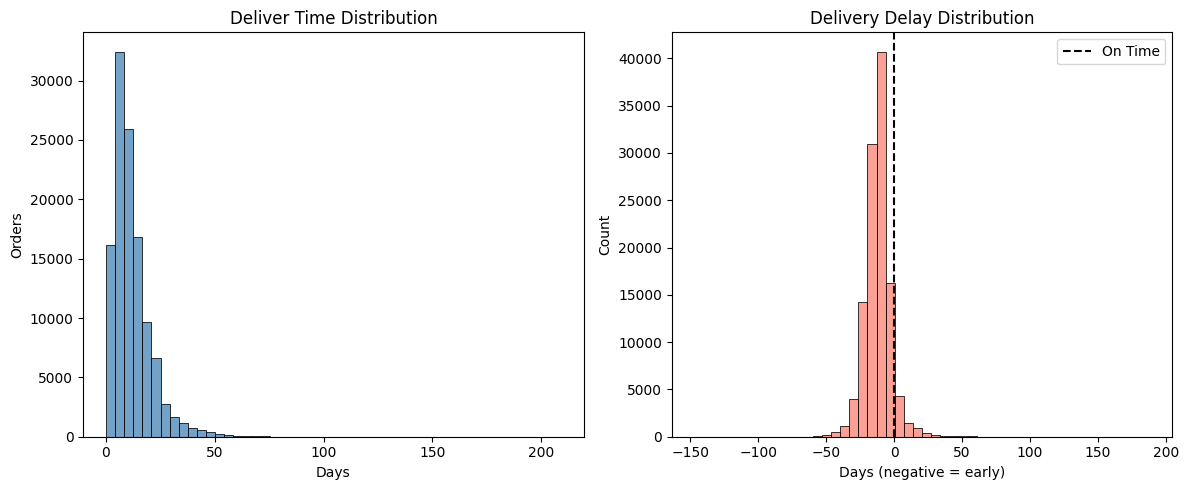

Average Delivery Time: 12.0 days
Average Delivery Delay: -12.0days
% Late Orders: 6.3%


In [113]:
#  Delivery Time Distribution 
#Q1: What is the typical delivery experience for customers?
plt.figure(figsize =(12,5))

plt.subplot(1,2,1)
sns.histplot(df['delivery_time'].dropna(), bins = 50, color ='steelblue')
plt.title("Deliver Time Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")

plt.subplot(1,2,2)
sns.histplot(df['delivery_delay'].dropna(), bins= 50,color='salmon')
plt.axvline(0, color ='black', linestyle ='--', label ='On Time')
plt.title("Delivery Delay Distribution")
plt.xlabel("Days (negative = early)")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Average Delivery Time: {df['delivery_time'].mean():.1f} days")
print(f"Average Delivery Delay: {df['delivery_delay'].mean():.1f}days")
print(f"% Late Orders: {(df['delivery_delay'] > 0).mean()*100:.1f}%")

### Insight — Delivery Experience
- Most orders delivered within 5-20 days
- Negative average delay means majority delivered before estimated date
- Small % of late orders likely responsible for low review scores

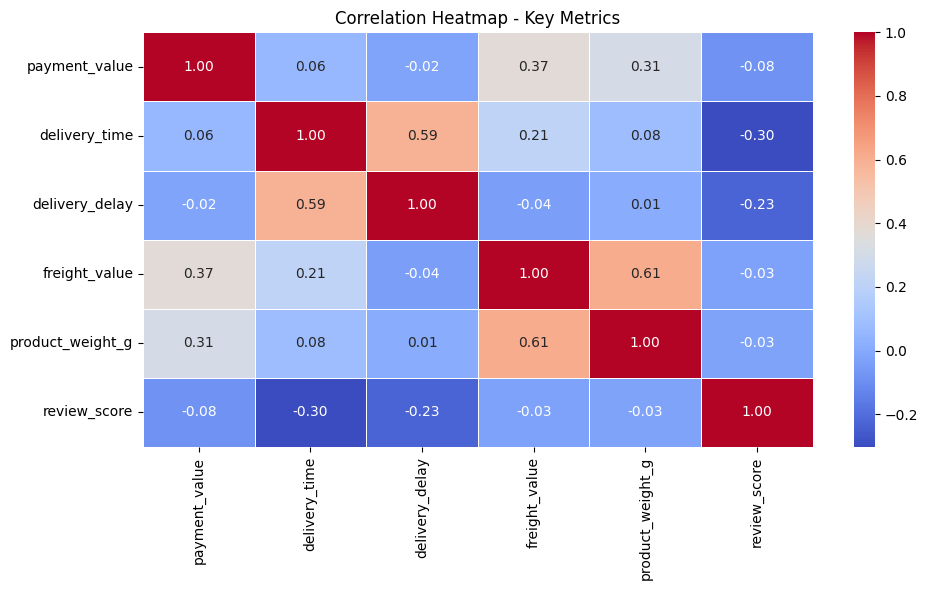

In [114]:
# Correlation Heatmap
# Q2: How do key metrics relate to each other?

plt.figure(figsize =(10,6))
numeric_cols = df[['payment_value','delivery_time','delivery_delay','freight_value','product_weight_g','review_score']].dropna()

sns.heatmap(numeric_cols.corr(),
            annot = True,
            cmap ='coolwarm',
            fmt ='.2f',
            linewidths = 0.5)
plt.title("Correlation Heatmap - Key Metrics")
plt.tight_layout()
plt.show()

### Insight — Correlations
- Delivery delay negatively correlates with review score → late = unhappy customers
- Freight value strongly correlates with product weight → heavier = costlier shipping
- Payment value has weak correlation with delivery time → price doesn't affect speed

C:\Users\TEST\AppData\Local\Temp\ipykernel_16916\860736791.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delay_review, x='review_score', y='delivery_delay', palette='RdYlGn')


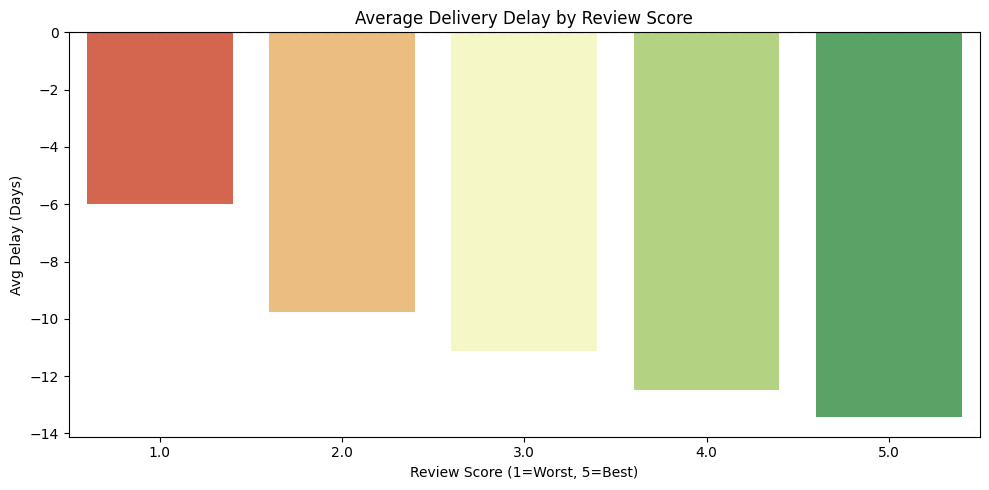

   review_score  delivery_delay
0           1.0       -5.993827
1           2.0       -9.748141
2           3.0      -11.114301
3           4.0      -12.468533
4           5.0      -13.443437


In [115]:
#Delay vs Review Score
# Q3: Do late deliveries directly hurt customer ratings?
plt.figure(figsize=(10,5))

delay_review = df.groupby('review_score')['delivery_delay'].mean().reset_index()

sns.barplot(data=delay_review, x='review_score', y='delivery_delay', palette='RdYlGn')
plt.axhline(0, color='black', linestyle='--')
plt.title("Average Delivery Delay by Review Score")
plt.xlabel("Review Score (1=Worst, 5=Best)")
plt.ylabel("Avg Delay (Days)")
plt.tight_layout()
plt.show()

print(delay_review)

### Insight — Delay vs Rating
- 1-star reviews have highest average delay → late delivery = worst ratings
- 5-star reviews have negative delay → early delivery = happy customers
- Clear pattern: every extra day of delay reduces customer satisfaction

C:\Users\TEST\AppData\Local\Temp\ipykernel_16916\1877281068.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_revenue, x='payment_value', y='product_category_name_english',


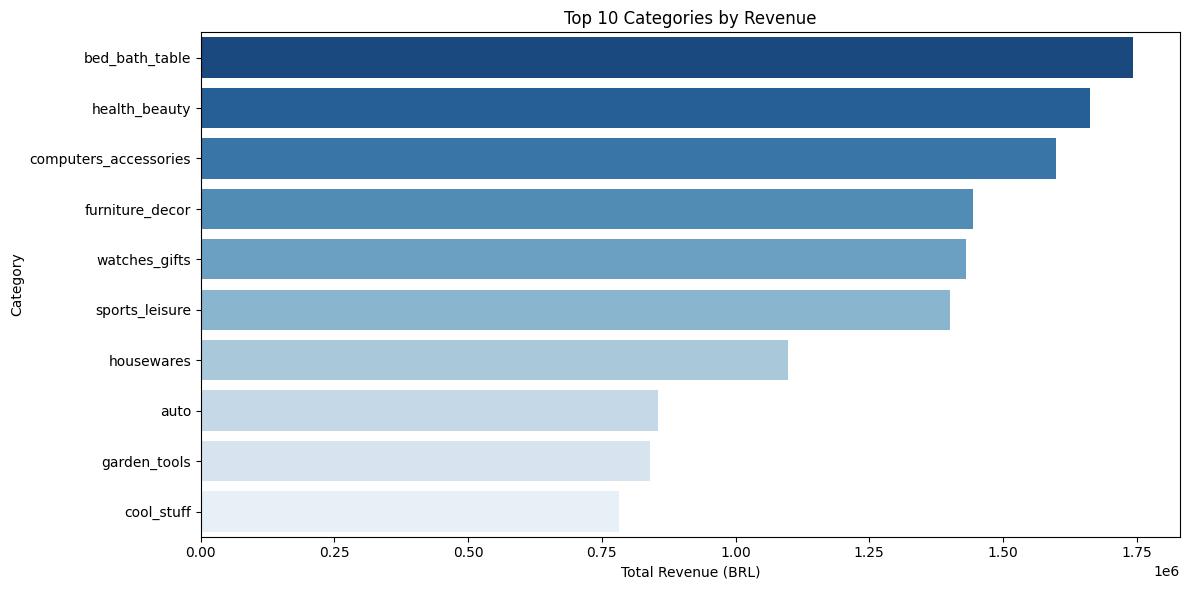

In [116]:
#Top Categories by Revenue
# Q4: Which product categories drive most revenue?
plt.figure(figsize=(12,6))

cat_revenue = df.groupby('product_category_name_english')['payment_value'].sum()\
               .sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=cat_revenue, x='payment_value', y='product_category_name_english',
            palette='Blues_r')
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Insight — Top Categories
- Health & beauty and watches lead revenue
- Electronics categories have high value per order
- Top 3 categories contribute disproportionate share of total revenue

C:\Users\TEST\AppData\Local\Temp\ipykernel_16916\2561663628.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_rev, x='payment_value', y='customer_state',
C:\Users\TEST\AppData\Local\Temp\ipykernel_16916\2561663628.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_ord, x='order_id', y='customer_state',


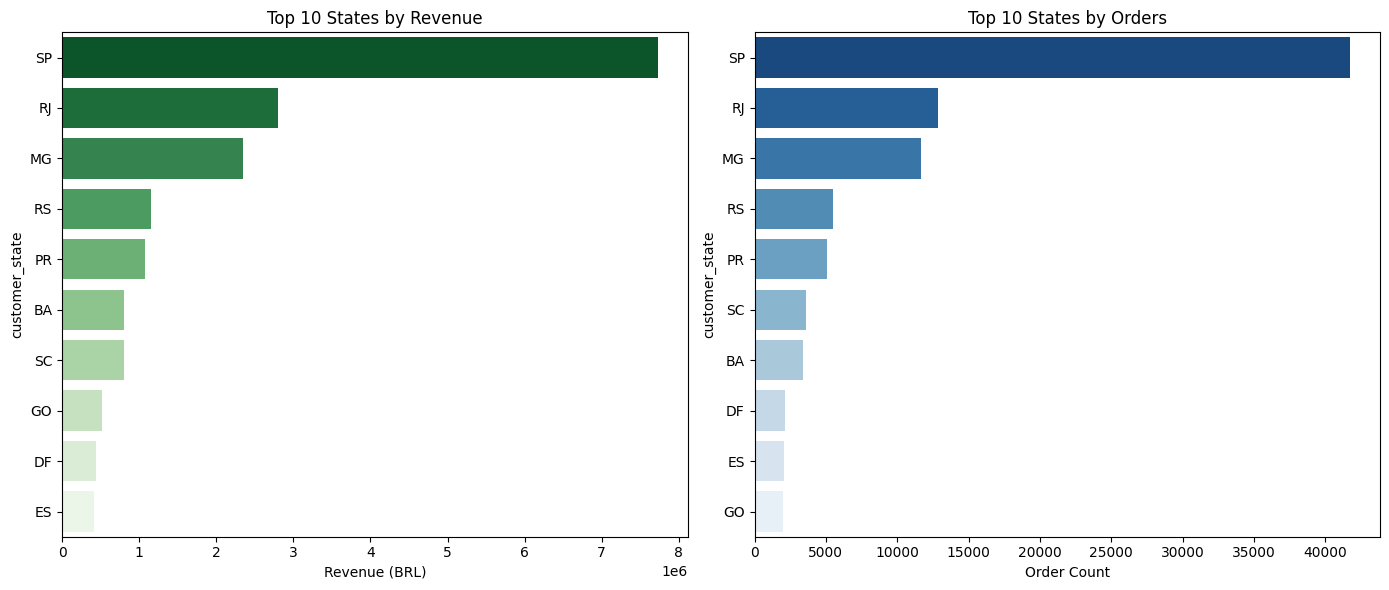

In [117]:
#State Revenue vs Order Volume
# Q5: Which states generate highest revenue and order volume?
fig, axes = plt.subplots(1,2, figsize=(14,6))

state_rev = df.groupby('customer_state')['payment_value'].sum()\
              .sort_values(ascending=False).head(10).reset_index()
state_ord = df.groupby('customer_state')['order_id'].nunique()\
              .sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=state_rev, x='payment_value', y='customer_state',
            palette='Greens_r', ax=axes[0])
axes[0].set_title("Top 10 States by Revenue")
axes[0].set_xlabel("Revenue (BRL)")

sns.barplot(data=state_ord, x='order_id', y='customer_state',
            palette='Blues_r', ax=axes[1])
axes[1].set_title("Top 10 States by Orders")
axes[1].set_xlabel("Order Count")

plt.tight_layout()
plt.show()

### Insight — State Performance
- SP (São Paulo) dominates both revenue and order volume
- RJ and MG follow but gap is significant
- Smaller states present growth opportunity if delivery times improve

C:\Users\TEST\AppData\Local\Temp\ipykernel_16916\1557370821.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seller_perf, x='total_revenue', y='seller_id', palette='Oranges_r')


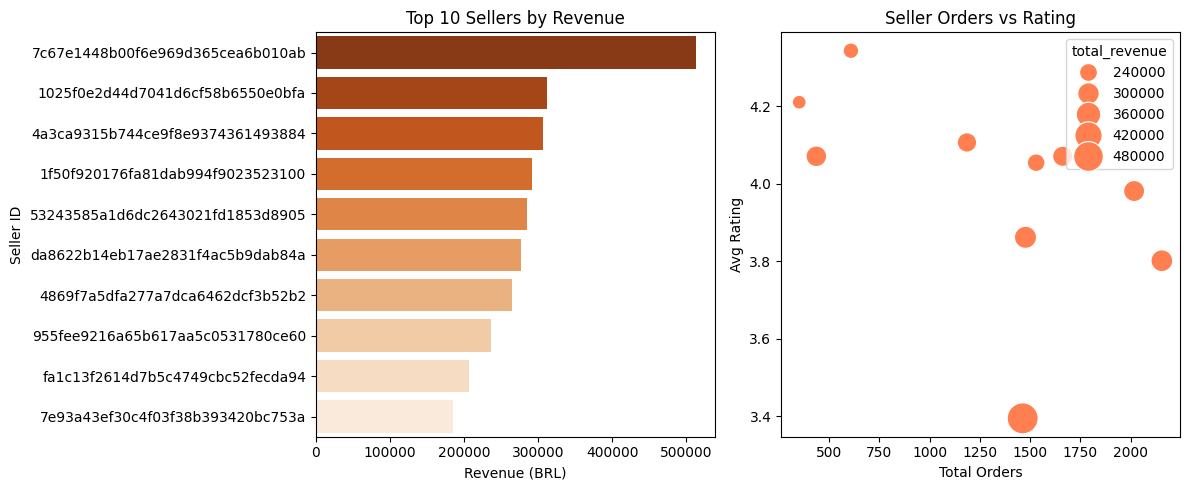

In [118]:
#Seller Performance
# Q6: Who are the top performing sellers?
plt.figure(figsize=(12,5))

seller_perf = df.groupby('seller_id').agg(
    total_revenue=('payment_value','sum'),
    total_orders=('order_id','count'),
    avg_rating=('review_score','mean')
).sort_values('total_revenue', ascending=False).head(10).reset_index()

plt.subplot(1,2,1)
sns.barplot(data=seller_perf, x='total_revenue', y='seller_id', palette='Oranges_r')
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue (BRL)")
plt.ylabel("Seller ID")

plt.subplot(1,2,2)
sns.scatterplot(data=seller_perf, x='total_orders', y='avg_rating',
                size='total_revenue', sizes=(100,500), color='coral')
plt.title("Seller Orders vs Rating")
plt.xlabel("Total Orders")
plt.ylabel("Avg Rating")

plt.tight_layout()
plt.show()

### Insight — Seller Performance
- Top sellers by revenue don't always have highest ratings
- High order volume sellers maintain consistent ratings
- Low rating high revenue sellers = risk of customer churn

#Final Summary
## Key Business Findings

1. **Delivery drives satisfaction** — late deliveries directly cause 1-star reviews
2. **SP dominates** — São Paulo accounts for majority of orders and revenue
3. **Health & Beauty leads** — top revenue category with growth potential
4. **Most orders arrive early** — negative average delay is a competitive strength
5. **Top sellers need rating monitoring** — high revenue ≠ high satisfaction